In [1]:
import tensorflow as tf
print(tf.__version__)

2.10.1


In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from collections import Counter
import itertools
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [4]:
X_train=pd.read_csv('X_train.csv',index_col=False)
X_val=pd.read_csv('X_val.csv',index_col=False)
X_test=pd.read_csv('X_test.csv',index_col=False)
y_train=pd.read_csv('y_train.csv',index_col=False)
y_val=pd.read_csv('y_val.csv',index_col=False)
y_test=pd.read_csv('y_test.csv',index_col=False)

In [5]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)

(183861, 3)
(20000, 3)
(183861, 1)
(20000, 1)
(15000, 3)
(15000, 1)


In [6]:
X_train.sample(5)

,Tweet,Cleaned_Tweet,Final_Cleaned_Tweet
177020,Trucker Freedom Convoy Getting Too Big to Spin...,trucker freedom convoy getting too big to spin...,trucker freedom convoy get big spin via
164666,"Believe it or not, China is legitimately point...",believe it or not china is legitimately pointi...,believe china legitimately point hypocrisy can...
139686,On Day 26 of the Emergencies Act hearings test...,on day of the emergencies act hearings testimo...,day emergency act hearing testimony reveal pm ...
37543,"@VirginiaMarkle I agree, wearing that poppy is...",i agree wearing that poppy is a insult to the ...,agree wear poppy insult brave canadian soldier...
12363,@IsFictional @jspence3217 @CornerDarcis @philm...,it a hard to have sympathy for pal who just do...,hard sympathy pal see reality virus political ...


## Lets explore the token lengths and vocabulary size of train set

In [7]:
# Step 1: Token length stats (for MAX_LEN)
X_train_tokens = X_train["Final_Cleaned_Tweet"].astype(str).apply(lambda x: len(x.split()))


In [8]:
X_train_tokens.head(2)

0    10
1    13
Name: Final_Cleaned_Tweet, dtype: int64

In [9]:
# Summary statistics for sequence lengths
max_len_stats = {
    "Min Length": X_train_tokens.min(),
    "Max Length": X_train_tokens.max(),
    "Mean Length": X_train_tokens.mean(),
    "Median Length": X_train_tokens.median(),
    "95th Percentile": X_train_tokens.quantile(0.95),
    "99th Percentile": X_train_tokens.quantile(0.99)
}


In [10]:
# Print recommended MAX_LEN based on 99th percentile
recommended_max_len = int(X_train_tokens.quantile(0.99))
print("Recommended MAX_LEN (99th percentile):", recommended_max_len)
print("Token Length Stats:", max_len_stats)

Recommended MAX_LEN (99th percentile): 30
Token Length Stats: {'Min Length': 1, 'Max Length': 108, 'Mean Length': 14.21446636317653, 'Median Length': 13.0, '95th Percentile': 26.0, '99th Percentile': 30.0}


In [11]:
# Fit tokenizer on raw training data
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train["Final_Cleaned_Tweet"].astype(str))


In [12]:
# Total number of unique words
vocab_size = len(tokenizer.word_index)
print("Actual Vocabulary Size (before cutoff):", vocab_size)

Actual Vocabulary Size (before cutoff): 55258


In [ ]:

# Ensure all values are strings (replace NaN with empty string)
cleaned_tweets = X_train["Final_Cleaned_Tweet"].fillna("").astype(str)

# Tokenize and flatten all tokens
all_tokens = list(itertools.chain.from_iterable([text.split() for text in cleaned_tweets]))

# Count token frequencies
word_freq = Counter(all_tokens)

# Show top 10 most frequent words
most_common_words = word_freq.most_common(5)
print("Top 10 Most Common Words:", most_common_words)
print("Total Unique Words:", len(word_freq))

Top 10 Most Common Words: [('convoy', 132849), ('freedom', 129926), ('freedomconvoy', 56834), ('canada', 26997), ('ottawa', 26918), ('protest', 24624), ('trucker', 21853), ("'s", 21584), ('canadian', 20144), ('trudeau', 17925)]
Total Unique Words: 55260


## Lets Tokenazation and add padding to our input before feeding it to our model

In [14]:
# Parameters
MAX_VOCAB = 10000
MAX_LEN = 32

In [15]:
X_train_texts = X_train["Final_Cleaned_Tweet"].fillna("").astype(str).tolist()
X_val_texts   = X_val["Final_Cleaned_Tweet"].fillna("").astype(str).tolist()
X_test_texts  = X_test["Final_Cleaned_Tweet"].fillna("").astype(str).tolist()

In [16]:
X_train_texts[100]

"wow hurt canada reputation national security threat damn n't book freedomconvoy emergenciesactinquiry trudeaumustgo cannoli"

In [17]:
# Tokenizer setup
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")


In [18]:
tokenizer.fit_on_texts(X_train_texts)

In [19]:
# Convert texts to padded sequences
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_texts), maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val_texts), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_texts), maxlen=MAX_LEN, padding="post", truncating="post")

In [20]:
# Label encoding
label_encoder = LabelEncoder()
y_train_enc = to_categorical(label_encoder.fit_transform(y_train["Sentiment"]))
y_val_enc   = to_categorical(label_encoder.transform(y_val["Sentiment"]))
y_test_enc  = to_categorical(label_encoder.transform(y_test["Sentiment"]))

In [21]:
y_test_enc[0]

array([0., 0., 1.], dtype=float32)

In [22]:
label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [23]:
# Hyperparameters
MAX_VOCAB = 10000      # Top words to keep
MAX_LEN = 32           # Max sequence length
EMBED_DIM = 128        # Word/positional embedding size
NUM_HEADS = 4          # Multi-head attention heads
FF_DIM = 128           # Feedforward hidden layer
NUM_CLASSES = 3        # 'negative', 'neutral', 'positive'

# Lets build model layer by layer (positional embiddings layer , transformer layer , main block)

In [24]:
# Positional Embedding Layer
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [25]:
# Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)               # Non-causal: attends to full sequence
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)         # Residual + Norm
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

## single layer transformer

In [26]:
# Build Transformer Model
def build_transformer_model():
    inputs = layers.Input(shape=(MAX_LEN,))
    x = PositionalEmbedding(MAX_LEN, MAX_VOCAB, EMBED_DIM)(inputs)
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inputs, outputs)

In [27]:
# Compile and Show Summary
model_1 = build_transformer_model()
model_1.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_1.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32)]              0         
                                                                 
 positional_embedding (Posit  (None, 32, 128)          1284096   
 ionalEmbedding)                                                 
                                                                 
 transformer_block (Transfor  (None, 32, 128)          297344    
 merBlock)                                                       
                                                                 
 global_average_pooling1d (G  (None, 128)              0         
 lobalAveragePooling1D)                                          
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                             

In [28]:
# List physical GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" TensorFlow is using {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu}")
else:
    print("❌ No GPU detected. Using CPU.")

 TensorFlow is using 1 GPU(s):
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [29]:
history_1 = model_1.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=10,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/10


5746/5746 [==============================] - 48s 8ms/step - loss: 0.7258 - accuracy: 0.6819 - val_loss: 0.6633 - val_accuracy: 0.7147
Epoch 2/10
5746/5746 [==============================] - 43s 8ms/step - loss: 0.6305 - accuracy: 0.7329 - val_loss: 0.6254 - val_accuracy: 0.7339
Epoch 3/10
5746/5746 [==============================] - 98s 17ms/step - loss: 0.5843 - accuracy: 0.7532 - val_loss: 0.6270 - val_accuracy: 0.7336
Epoch 4/10
5746/5746 [==============================] - 102s 18ms/step - loss: 0.5543 - accuracy: 0.7670 - val_loss: 0.6331 - val_accuracy: 0.7345
Epoch 5/10
5746/5746 [==============================] - 104s 18ms/step - loss: 0.5267 - accuracy: 0.7795 - val_loss: 0.6474 - val_accuracy: 0.7426
Epoch 6/10
5746/5746 [==============================] - 104s 18ms/step - loss: 0.5020 - accuracy: 0.7900 - val_loss: 0.6639 - val_accuracy: 0.7455
Epoch 7/10
5746/5746 [==============================] - 103s 18ms/step - loss: 0.4796 - accuracy: 0.7987 - val_loss: 0.6460 - val_accu

In [30]:
from sklearn.metrics import confusion_matrix

def confusion_report_builtin(model, sets, labels, label_encoder):
    for (X_seq, y_enc), name in zip(sets, labels):
        print(f"\n{'='*10} {name} Set {'='*10}")
        y_pred = model.predict(X_seq).argmax(axis=1)
        y_true = y_enc.argmax(axis=1)

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        print("\nConfusion Matrix:")
        print(pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_))

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


In [31]:
def plot_train_val_history(history):
    """
    Plots training and validation loss and accuracy over epochs.
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(14, 5))

    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Train Loss', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Val Loss', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # --- Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', color='orange')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


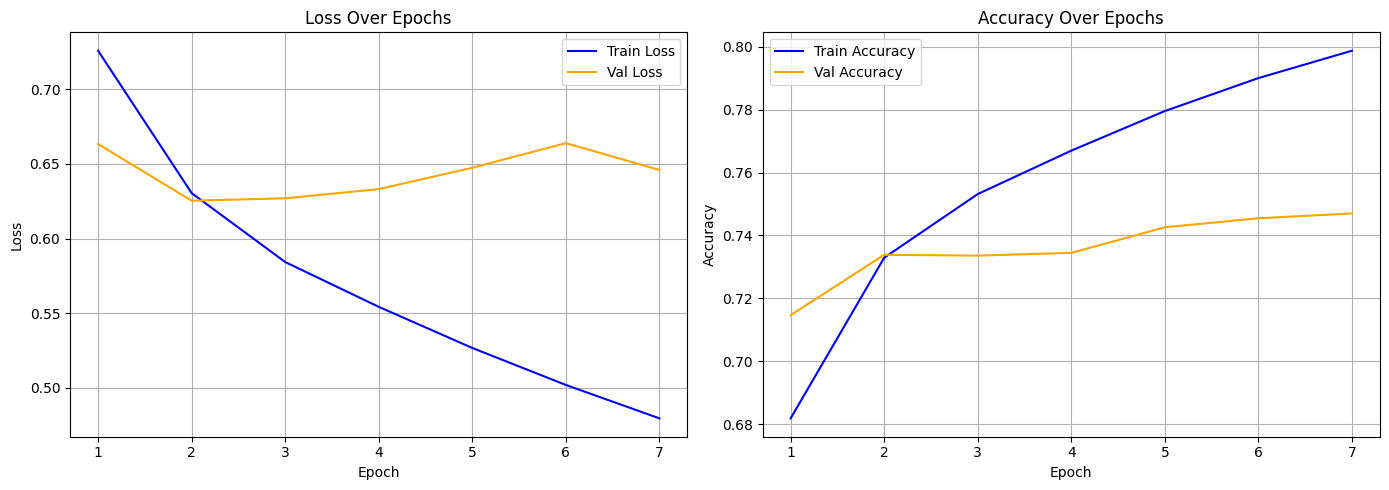

In [32]:
plot_train_val_history(history_1)


In [33]:
sets = [(X_train_seq, y_train_enc), (X_val_seq, y_val_enc), (X_test_seq, y_test_enc)]
labels = ["Train", "Val", "Test"]

confusion_report_builtin(model_1, sets, labels, label_encoder)


========== Train Set ==========
5746/5746 [==============================] - 40s 7ms/step

Confusion Matrix:
          negative  neutral  positive
negative     49349     4081      7857
neutral      12260    36841     12186
positive      4140     3354     53793

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.81      0.78     61287
     neutral       0.83      0.60      0.70     61287
    positive       0.73      0.88      0.80     61287

    accuracy                           0.76    183861
   macro avg       0.77      0.76      0.76    183861
weighted avg       0.77      0.76      0.76    183861


========== Val Set ==========
469/469 [==============================] - 3s 7ms/step

Confusion Matrix:
          negative  neutral  positive
negative      3964      393       643
neutral       1084     2815      1101
positive       418      353      4229

Classification Report:
              precision    recall  f1-score   suppor

In [34]:
def plot_multi_set_roc_auc(model, sets, labels, label_encoder):
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt

    assert len(sets) == len(labels), "Mismatch in number of datasets and labels"

    n_classes = sets[0][1].shape[1]
    class_names = list(label_encoder.classes_)

    # Fixed colors for consistency
    fixed_colors = {
        "negative": "red",
        "neutral": "blue",
        "positive": "green"
    }
    default_colors = ["red", "blue", "green", "purple", "orange", "brown", "pink"]
    linestyles = ['-', '--', ':'][:len(sets)]

    plt.figure(figsize=(12, 8))

    # Predict once per dataset
    predictions = [model.predict(X_seq) for (X_seq, _) in sets]

    for class_idx in range(n_classes):
        class_label = class_names[class_idx]
        color = fixed_colors.get(class_label, default_colors[class_idx % len(default_colors)])

        for set_idx, ((_, y_enc), set_name) in enumerate(zip(sets, labels)):
            y_score = predictions[set_idx]
            fpr, tpr, _ = roc_curve(y_enc[:, class_idx], y_score[:, class_idx])
            roc_auc_score = auc(fpr, tpr)
            plt.plot(
                fpr, tpr,
                color=color,
                linestyle=linestyles[set_idx],
                label=f"{class_label} ({set_name}) AUC = {roc_auc_score:.2f}"
            )

    plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC AUC per Class Across Sets")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


625/625 [==============================] - 4s 7ms/step


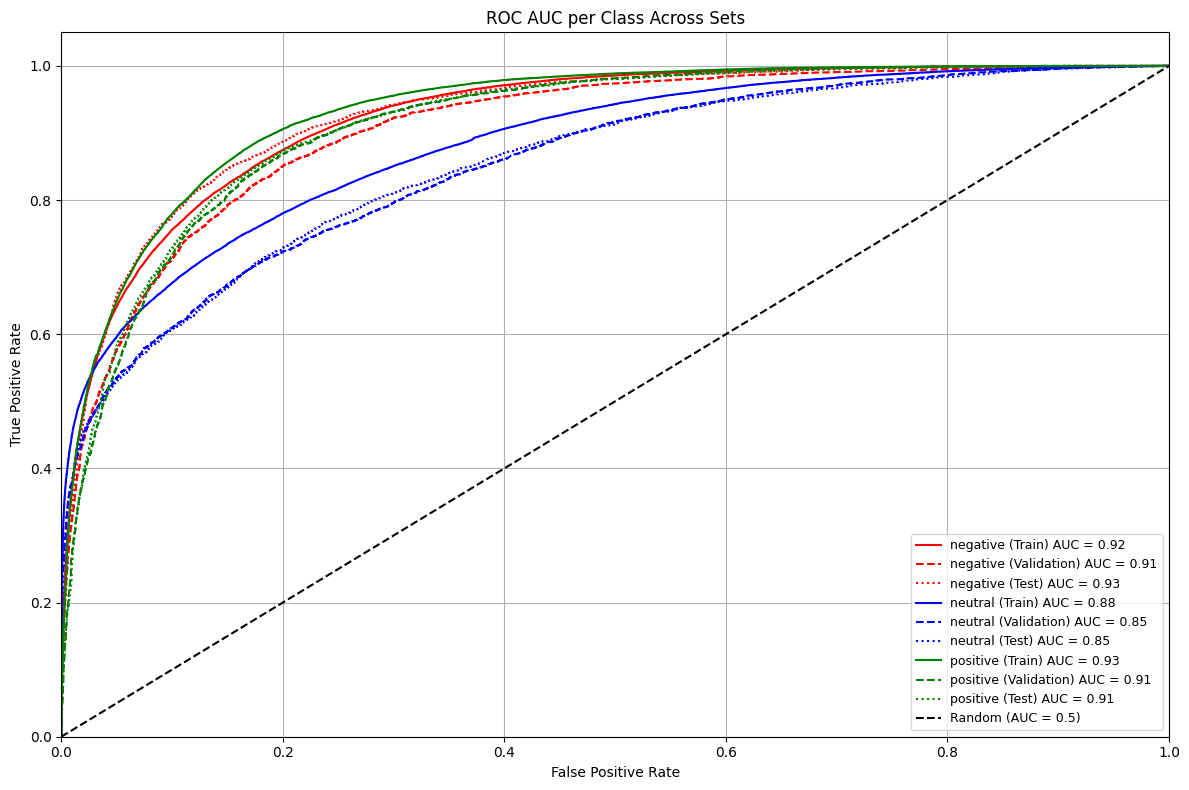

In [35]:
# Prepare your sets
sets = [
    (X_train_seq, y_train_enc),
    (X_val_seq, y_val_enc),
    (X_test_seq, y_test_enc)
]
labels = ["Train", "Validation", "Test"]

# Call the function
plot_multi_set_roc_auc(model_1, sets, labels, label_encoder)


In [36]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models

def build_non_causal_transformer_model(max_len=32, vocab_size=10000, embed_dim=128, num_heads=4, ff_dim=128, num_classes=3):
    inputs = tf.keras.Input(shape=(max_len,), name="input_tokens")

    # Embedding + Positional Encoding
    embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)

    # Add positional encodings manually
    positions = tf.range(start=0, limit=max_len, delta=1)
    pos_encoding_layer = layers.Embedding(input_dim=max_len, output_dim=embed_dim)(positions)
    x = embedding_layer + pos_encoding_layer

    # Transformer block (non-causal, full attention)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = layers.Dropout(0.3)(attn_output)  # 🔸 Dropout on transformer output
    attn_output = layers.LayerNormalization(epsilon=1e-6)(attn_output + x)

    # Feed-forward network
    ffn = layers.Dense(ff_dim, activation="relu")(attn_output)
    ffn = layers.Dropout(0.3)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(ffn + attn_output)

    # Global average pooling
    x = layers.GlobalAveragePooling1D()(x)

    # 🔸 Classifier Head (Deeper + Dropout + Regularization)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Compile with label smoothing
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    return model


In [37]:
model_2 = build_non_causal_transformer_model(
    max_len=MAX_LEN,            # e.g., 32
    vocab_size=MAX_VOCAB,       # e.g., 10000
    embed_dim=128,              # or 256
    num_heads=4,                # 2 or 4 heads is good for tweets
    ff_dim=128,                 # feed-forward units
    num_classes=3               # negative, neutral, positive
)
model_2.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 32)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 32, 128)      1280000     ['input_tokens[0][0]']           
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 32, 128)     0           ['embedding_2[0][0]']            
 da)                                                                                              
                                                                                                  
 multi_head_attention_1 (MultiH  (None, 32, 128)     263808      ['tf.__operators__.add[0][0

In [38]:
# Tokenized + padded data (already one-hot encoded y_train_enc etc.)
history_2 = model_2.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
2873/2873 [==============================] - 35s 11ms/step - loss: 0.9541 - accuracy: 0.6702 - val_loss: 0.7808 - val_accuracy: 0.7178
Epoch 2/30
2873/2873 [==============================] - 52s 18ms/step - loss: 0.7617 - accuracy: 0.7298 - val_loss: 0.7660 - val_accuracy: 0.7207
Epoch 3/30
2873/2873 [==============================] - 52s 18ms/step - loss: 0.7333 - accuracy: 0.7478 - val_loss: 0.7580 - val_accuracy: 0.7338
Epoch 4/30
2873/2873 [==============================] - 51s 18ms/step - loss: 0.7099 - accuracy: 0.7613 - val_loss: 0.7439 - val_accuracy: 0.7390
Epoch 5/30
2873/2873 [==============================] - 51s 18ms/step - loss: 0.6916 - accuracy: 0.7728 - val_loss: 0.7526 - val_accuracy: 0.7420
Epoch 6/30
2873/2873 [==============================] - 52s 18ms/step - loss: 0.6760 - accuracy: 0.7827 - val_loss: 0.7596 - val_accuracy: 0.7349
Epoch 7/30
2873/2873 [==============================] - 50s 18ms/step - loss: 0.6592 - accuracy: 0.7928 - val_loss: 0.7542 -

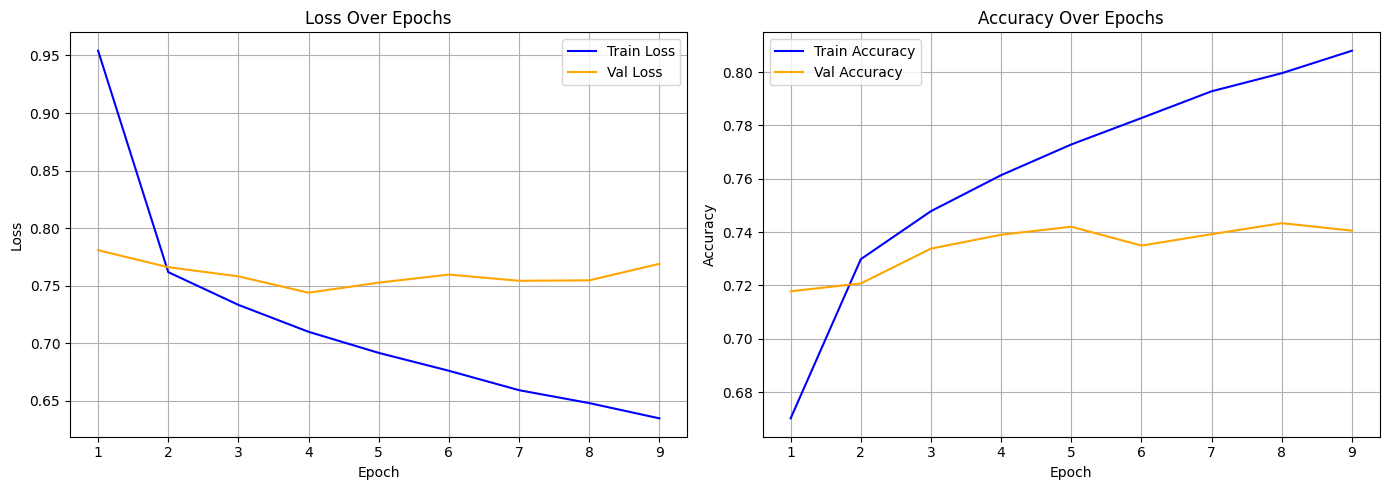

In [39]:
plot_train_val_history(history_2)

In [40]:
sets = [(X_train_seq, y_train_enc), (X_val_seq, y_val_enc), (X_test_seq, y_test_enc)]
labels = ["Train", "Val", "Test"]

confusion_report_builtin(model_2, sets, labels, label_encoder)


========== Train Set ==========
5746/5746 [==============================] - 33s 6ms/step

Confusion Matrix:
          negative  neutral  positive
negative     52140     2298      6849
neutral      13041    38494      9752
positive      5637     1824     53826

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.85      0.79     61287
     neutral       0.90      0.63      0.74     61287
    positive       0.76      0.88      0.82     61287

    accuracy                           0.79    183861
   macro avg       0.80      0.79      0.78    183861
weighted avg       0.80      0.79      0.78    183861


========== Val Set ==========
469/469 [==============================] - 3s 6ms/step

Confusion Matrix:
          negative  neutral  positive
negative      4109      288       603
neutral       1205     2812       983
positive       562      274      4164

Classification Report:
              precision    recall  f1-score   suppor

625/625 [==============================] - 4s 6ms/step


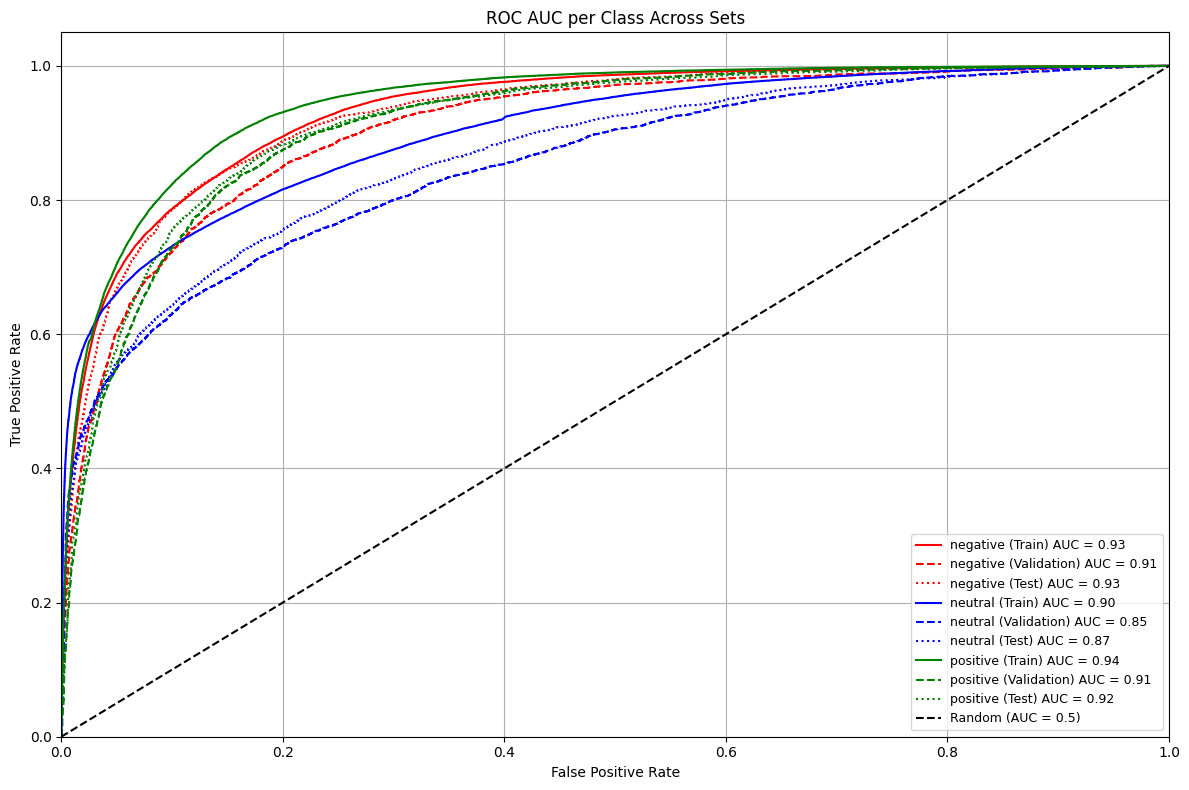

In [41]:
# Prepare your sets
sets = [
    (X_train_seq, y_train_enc),
    (X_val_seq, y_val_enc),
    (X_test_seq, y_test_enc)
]
labels = ["Train", "Validation", "Test"]

# Call the function
plot_multi_set_roc_auc(model_2, sets, labels, label_encoder)


In [42]:
model_3 = build_non_causal_transformer_model(
    max_len=MAX_LEN,            # e.g., 32
    vocab_size=MAX_VOCAB,       # e.g., 10000
    embed_dim=128,              # or 256
    num_heads=4,                # 2 or 4 heads is good for tweets
    ff_dim=128,                 # feed-forward units
    num_classes=3               # negative, neutral, positive
)
model_2.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 32)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 32, 128)      1280000     ['input_tokens[0][0]']           
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 32, 128)     0           ['embedding_2[0][0]']            
 da)                                                                                              
                                                                                                  
 multi_head_attention_1 (MultiH  (None, 32, 128)     263808      ['tf.__operators__.add[0][0

In [43]:
# Tokenized + padded data (already one-hot encoded y_train_enc etc.)
history_3 = model_3.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
11492/11492 [==============================] - 217s 19ms/step - loss: 0.9152 - accuracy: 0.6661 - val_loss: 0.8026 - val_accuracy: 0.7037
Epoch 2/30
11492/11492 [==============================] - 206s 18ms/step - loss: 0.7853 - accuracy: 0.7217 - val_loss: 0.7756 - val_accuracy: 0.7201
Epoch 3/30
11492/11492 [==============================] - 213s 19ms/step - loss: 0.7545 - accuracy: 0.7416 - val_loss: 0.7584 - val_accuracy: 0.7298
Epoch 4/30
11492/11492 [==============================] - 218s 19ms/step - loss: 0.7323 - accuracy: 0.7530 - val_loss: 0.7537 - val_accuracy: 0.7339
Epoch 5/30
11492/11492 [==============================] - 220s 19ms/step - loss: 0.7144 - accuracy: 0.7643 - val_loss: 0.7705 - val_accuracy: 0.7350
Epoch 6/30
11492/11492 [==============================] - 219s 19ms/step - loss: 0.6999 - accuracy: 0.7727 - val_loss: 0.7560 - val_accuracy: 0.7409
Epoch 7/30
11492/11492 [==============================] - 223s 19ms/step - loss: 0.6875 - accuracy: 0.7804

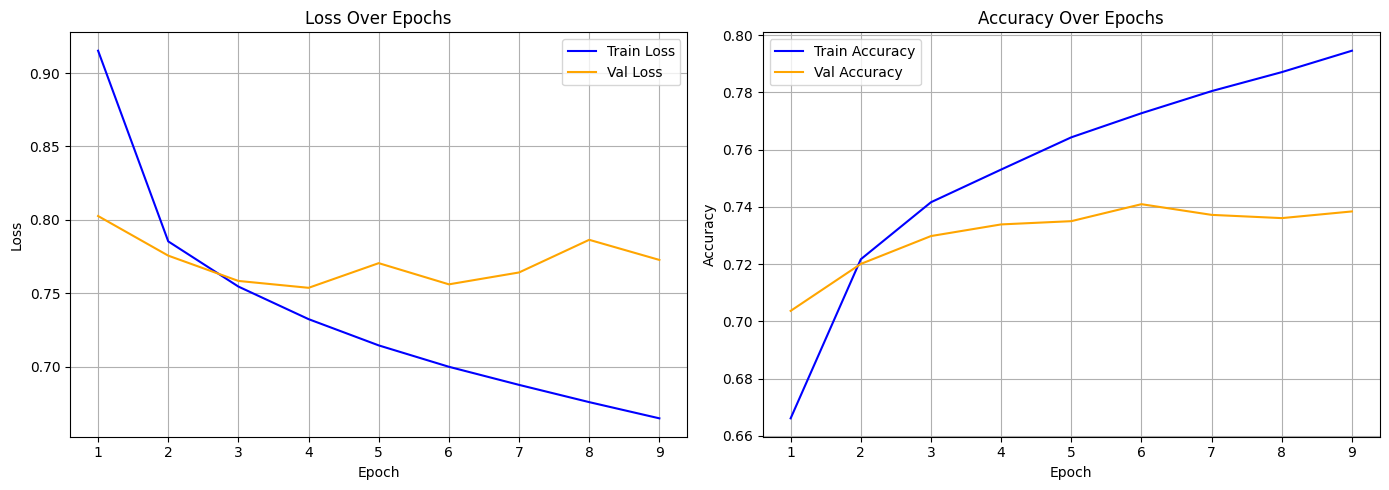

In [44]:
plot_train_val_history(history_3)

In [45]:
sets = [(X_train_seq, y_train_enc), (X_val_seq, y_val_enc), (X_test_seq, y_test_enc)]
labels = ["Train", "Val", "Test"]

confusion_report_builtin(model_3, sets, labels, label_encoder)


========== Train Set ==========
5746/5746 [==============================] - 34s 6ms/step

Confusion Matrix:
          negative  neutral  positive
negative     51553     1852      7882
neutral      13094    35556     12637
positive      4722     1448     55117

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.84      0.79     61287
     neutral       0.92      0.58      0.71     61287
    positive       0.73      0.90      0.81     61287

    accuracy                           0.77    183861
   macro avg       0.80      0.77      0.77    183861
weighted avg       0.80      0.77      0.77    183861


========== Val Set ==========
469/469 [==============================] - 3s 6ms/step

Confusion Matrix:
          negative  neutral  positive
negative      4091      219       690
neutral       1209     2618      1173
positive       499      202      4299

Classification Report:
              precision    recall  f1-score   suppor

625/625 [==============================] - 4s 6ms/step


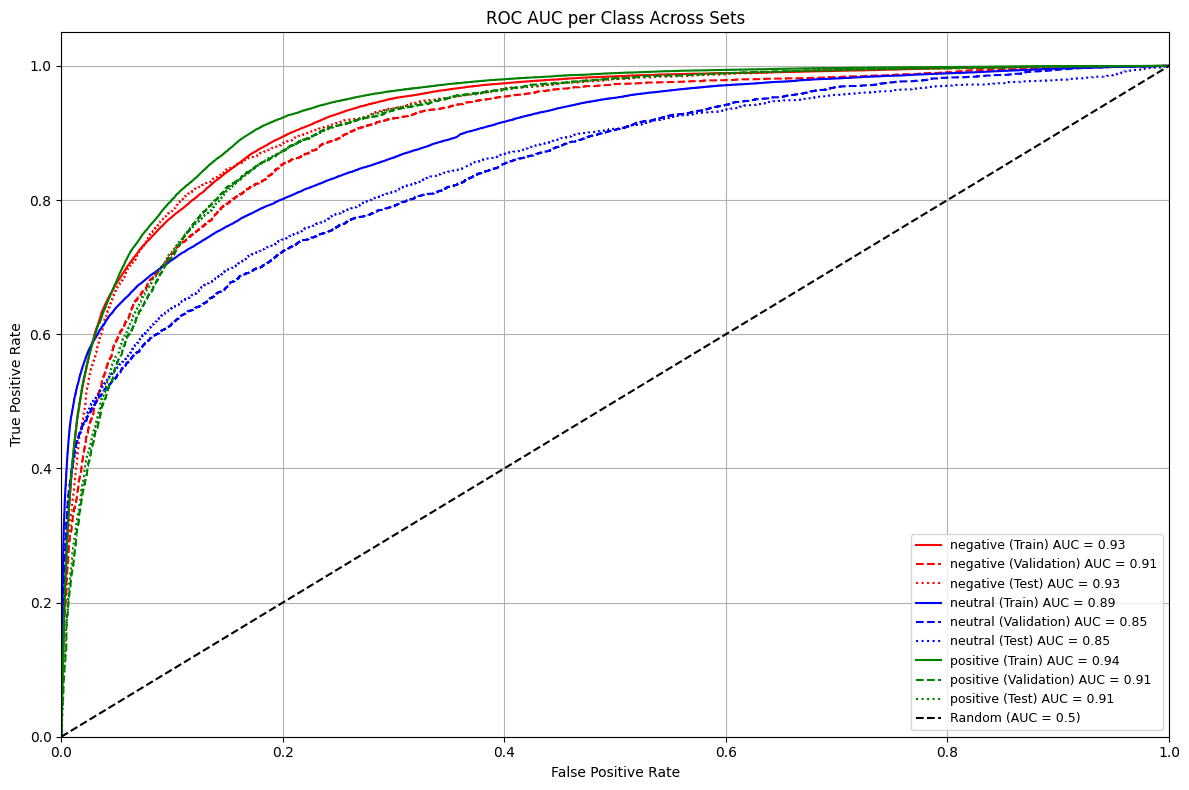

In [46]:
# Prepare your sets
sets = [
    (X_train_seq, y_train_enc),
    (X_val_seq, y_val_enc),
    (X_test_seq, y_test_enc)
]
labels = ["Train", "Validation", "Test"]

# Call the function
plot_multi_set_roc_auc(model_3, sets, labels, label_encoder)
